# Memory experiment, one setting at a time

In [27]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "src")

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display

from floquet import memory_circuit
from memory import count_logical_errors, sweep
from noise import NOISE_MODELS, add_noise, biased_single_qubit_probabilities
from plots import draw_ler, layout_figure, round_svg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# The Makefile's defaults. Change them here to see the effect below.
DISTANCES = [3, 5, 7]
NOISE = "spin"
ETA = 10.0
SHOTS = 100_000
P_MIN, P_MAX = 1e-4, 1e-2
NUM = 9
DRAW_DISTANCE = 1
NUMBERS = True  # label every qubit in the layouts: Di data, Sk / Rk syndrome / reference

## `DISTANCES`

Each distance is its own circuit, with rounds = distance. Detectors grow as ~d³ (~d² checks for d rounds),
which is where the d³ in the Makefile's run-time estimate comes from.

In [29]:
for d in DISTANCES:
    c = memory_circuit(d, d)
    print(f"d = {d}: {c.num_ticks:>3} layers, {c.num_measurements:>4} measurements, {c.num_detectors:>4} detectors")

d = 3:  21 layers,   33 measurements,   24 detectors
d = 5:  35 layers,  145 measurements,  120 detectors
d = 7:  49 layers,  385 measurements,  336 detectors


The timeslice view of the first distance, one panel per `TICK` layer. `make timeslices` saves this as a PNG.

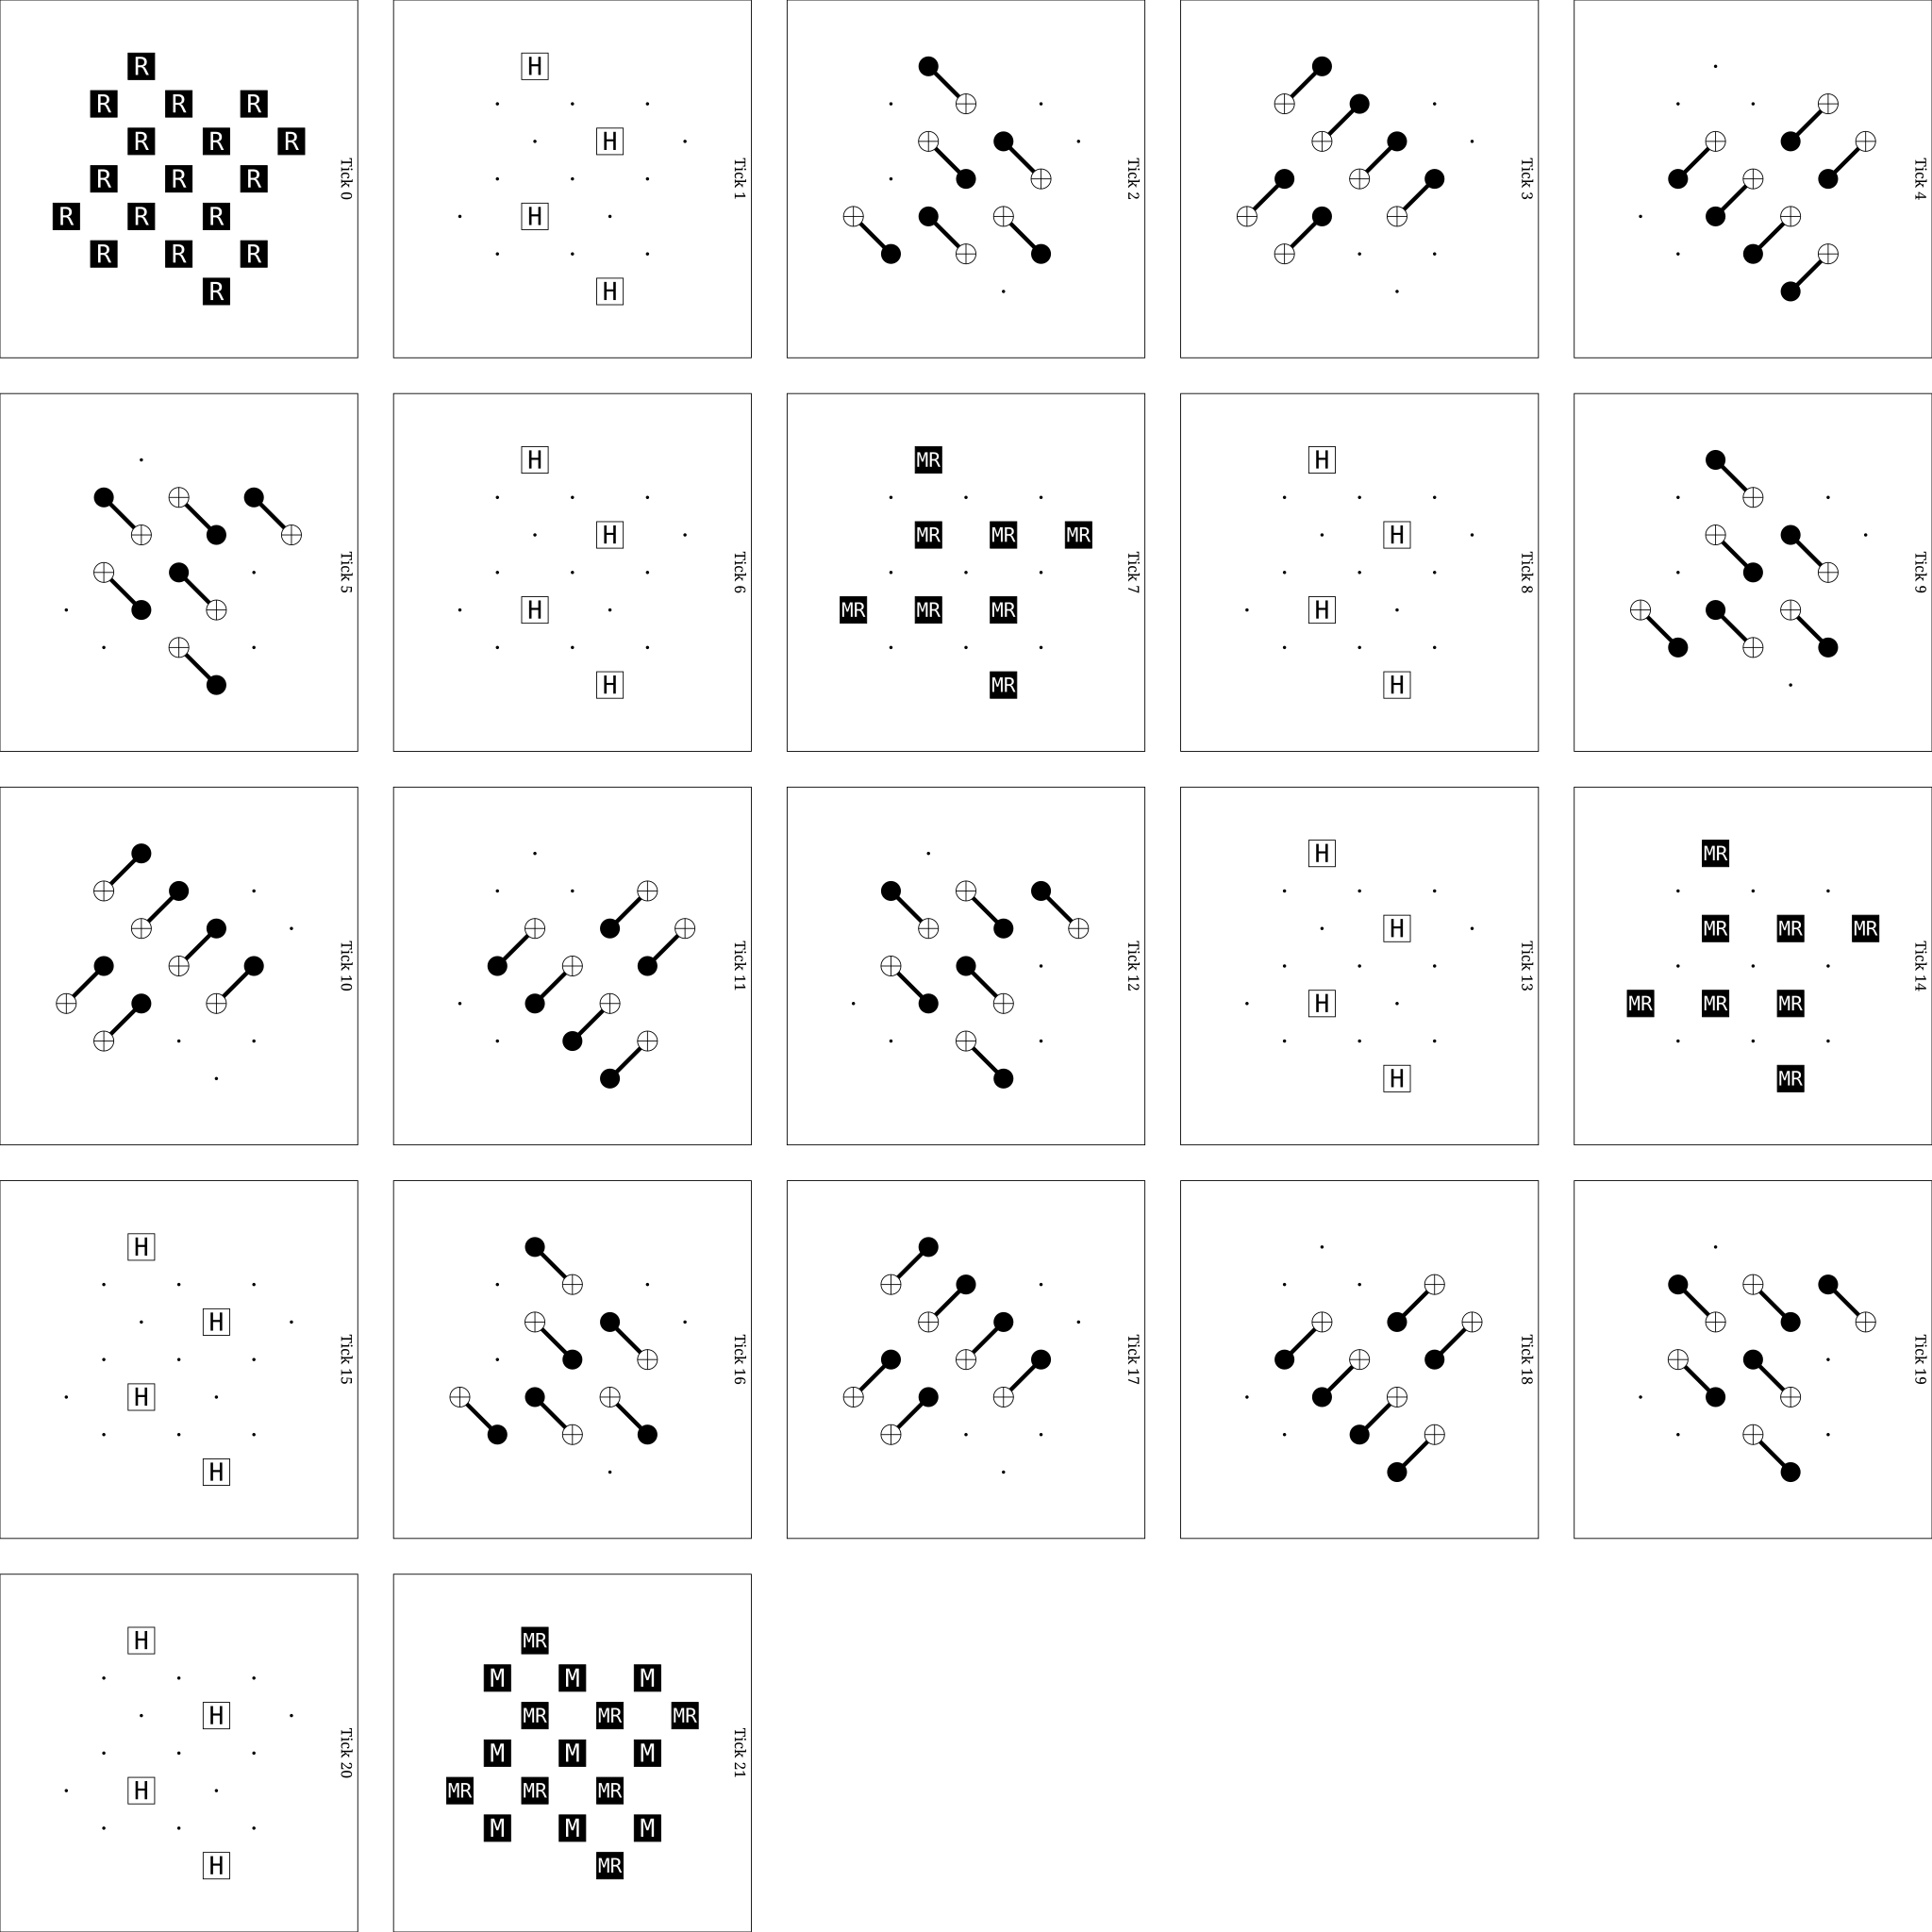

In [30]:
memory_circuit(DISTANCES[0], DISTANCES[0]).diagram("timeslice-svg")

## `DRAW_DISTANCE`: the honeycomb lattice

The Floquet code's lattice, which `make honeycomb` draws. Hexagonal plaquettes sit on a torus of
2·d columns by 3·d rows, coloured 0, 1, 2 so that neighbours never match.
The colour says *when*: sub-round r checks every edge linking two colour-r plaquettes (the edge points into
a colour-r plaquette at each end, and runs between two plaquettes of the other colours). A colour-r
plaquette's value is then read off from its six sides, which are checked in the two other sub-rounds. Data qubits sit on the corners
(filled), here in the brick-wall layout the circuits use: 12·d² of them. Since these are spin qubits, each of
the 18·d² edges also has two ancillas between its data qubits, read out together by spin blockade: the
syndrome ancilla that does the calculation (white, next to the edge's first data qubit) and its reference
(grey), held in a known state for the readout. The plot shows one
torus period, so an edge that wraps around the boundary still has its ancillas on a plaquette side.

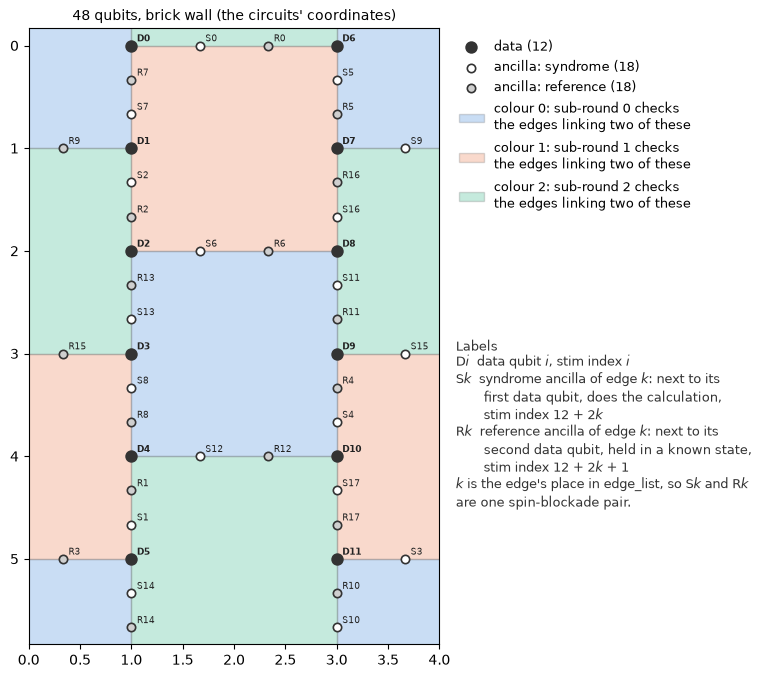

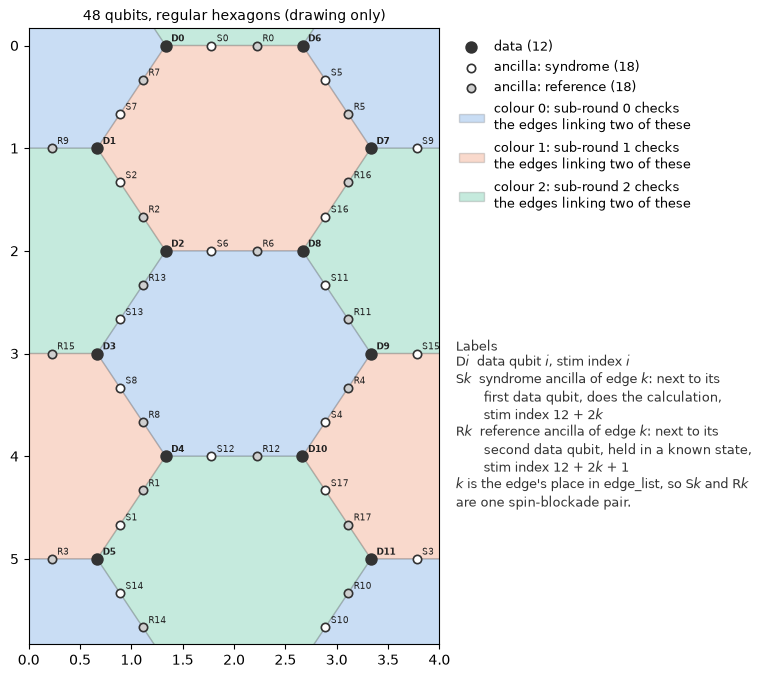

In [31]:
for hex_view in (False, True):
    layout_figure(DRAW_DISTANCE, hex_view, NUMBERS)

The three sub-rounds. An edge's colour is the colour of the two plaquettes it connects, and sub-round r
measures every colour-r edge: H / H_YZ turn its XX or YY parity into ZZ, the CNOT folds that onto the
pair's second qubit, M reads it, then the CNOT and Hadamards are undone. Every qubit is in exactly one
measured pair per sub-round. Edges that wrap around the torus are drawn as long arcs.

sub-round 0


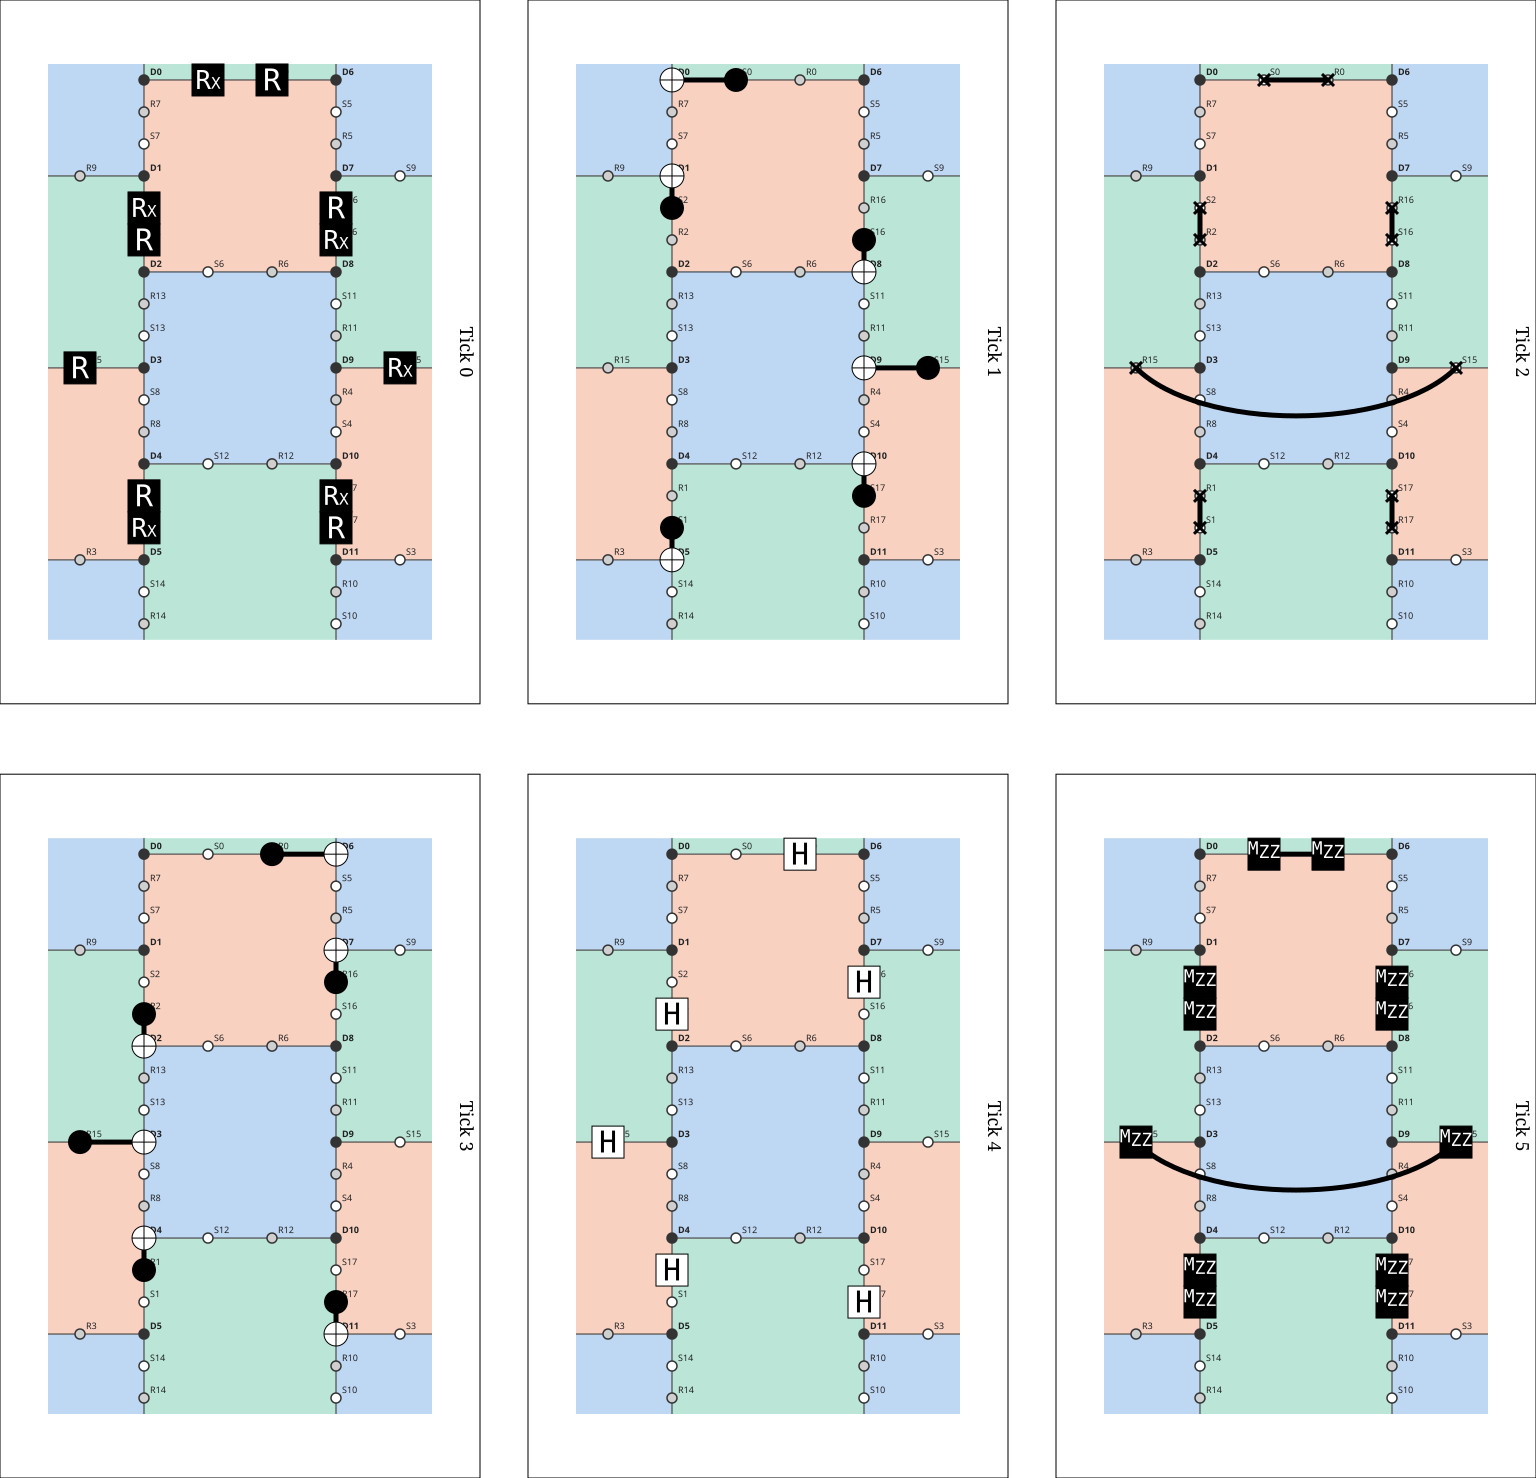

sub-round 1


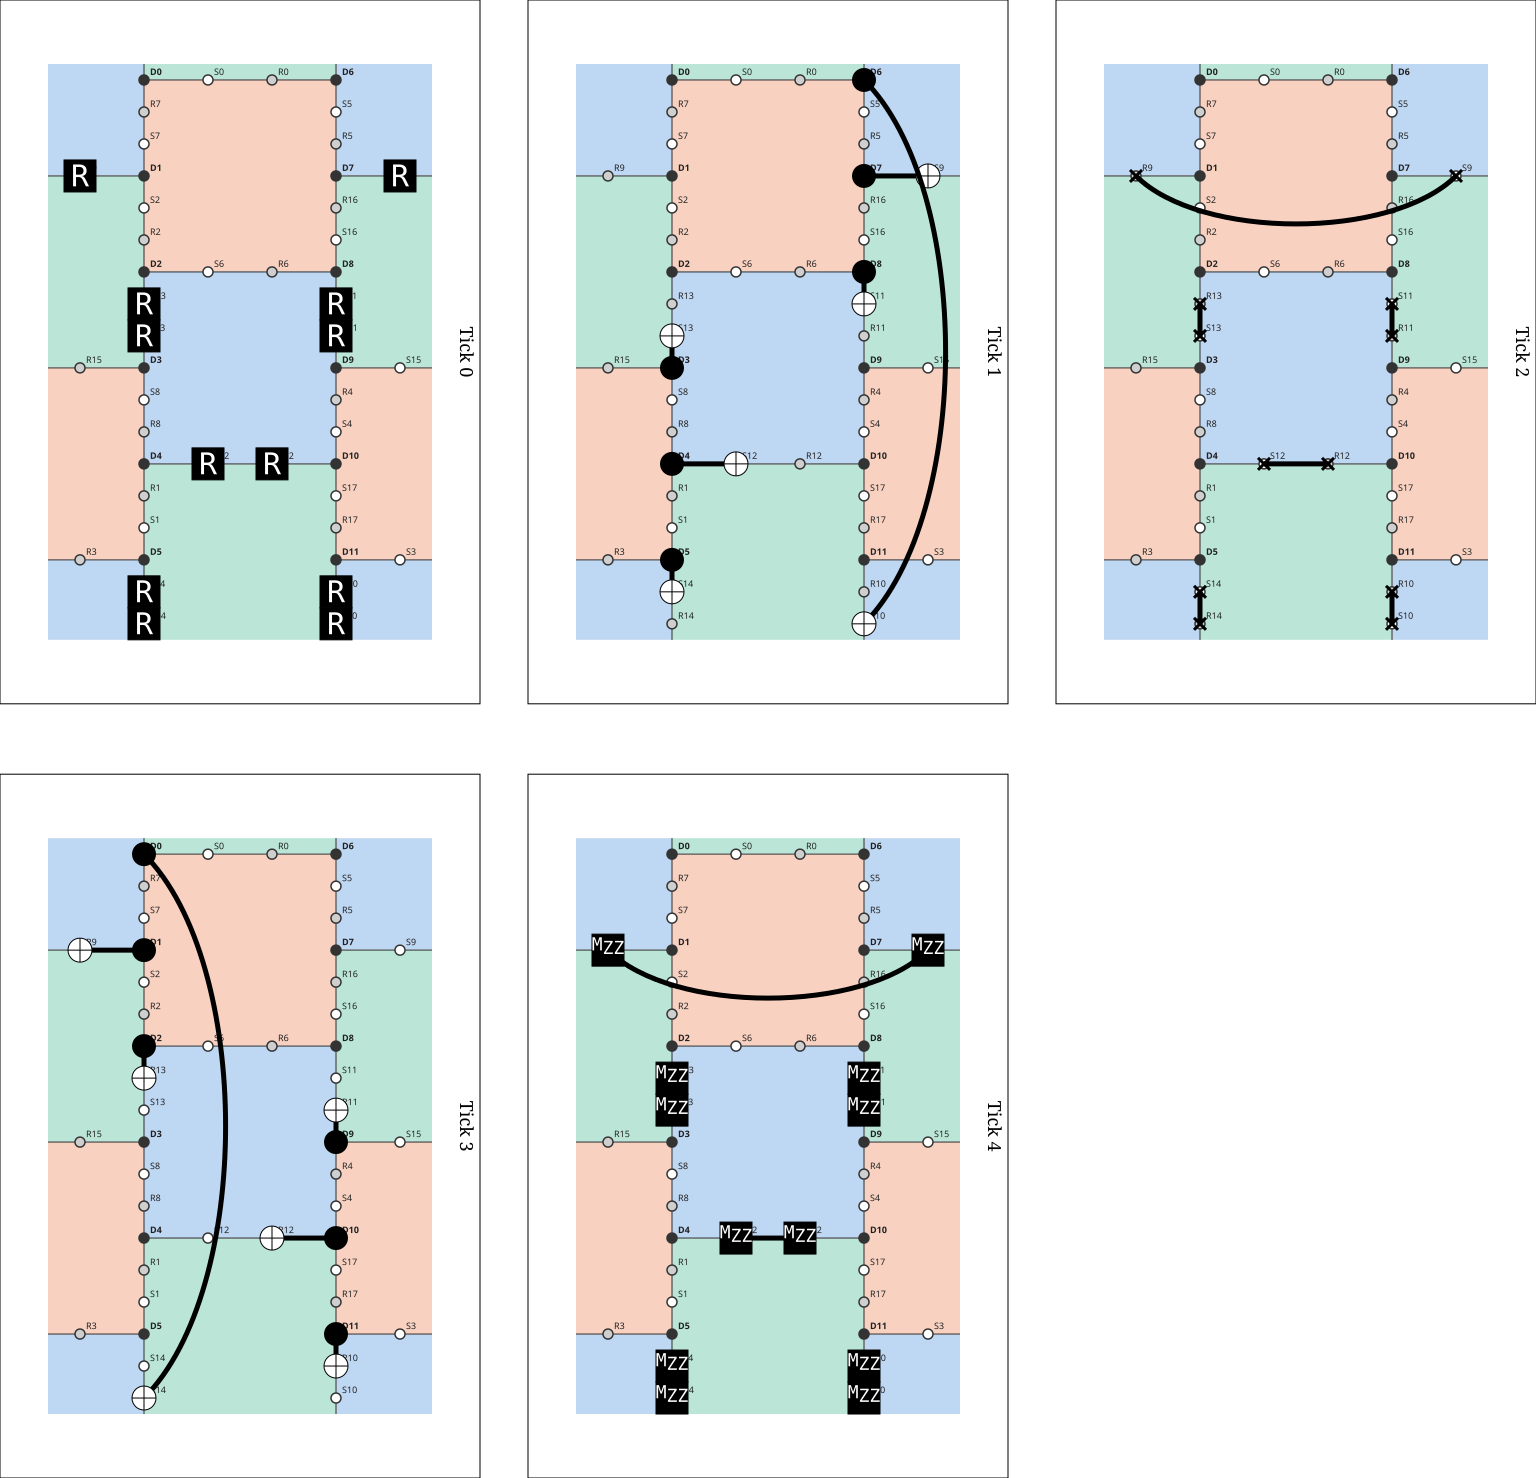

sub-round 2


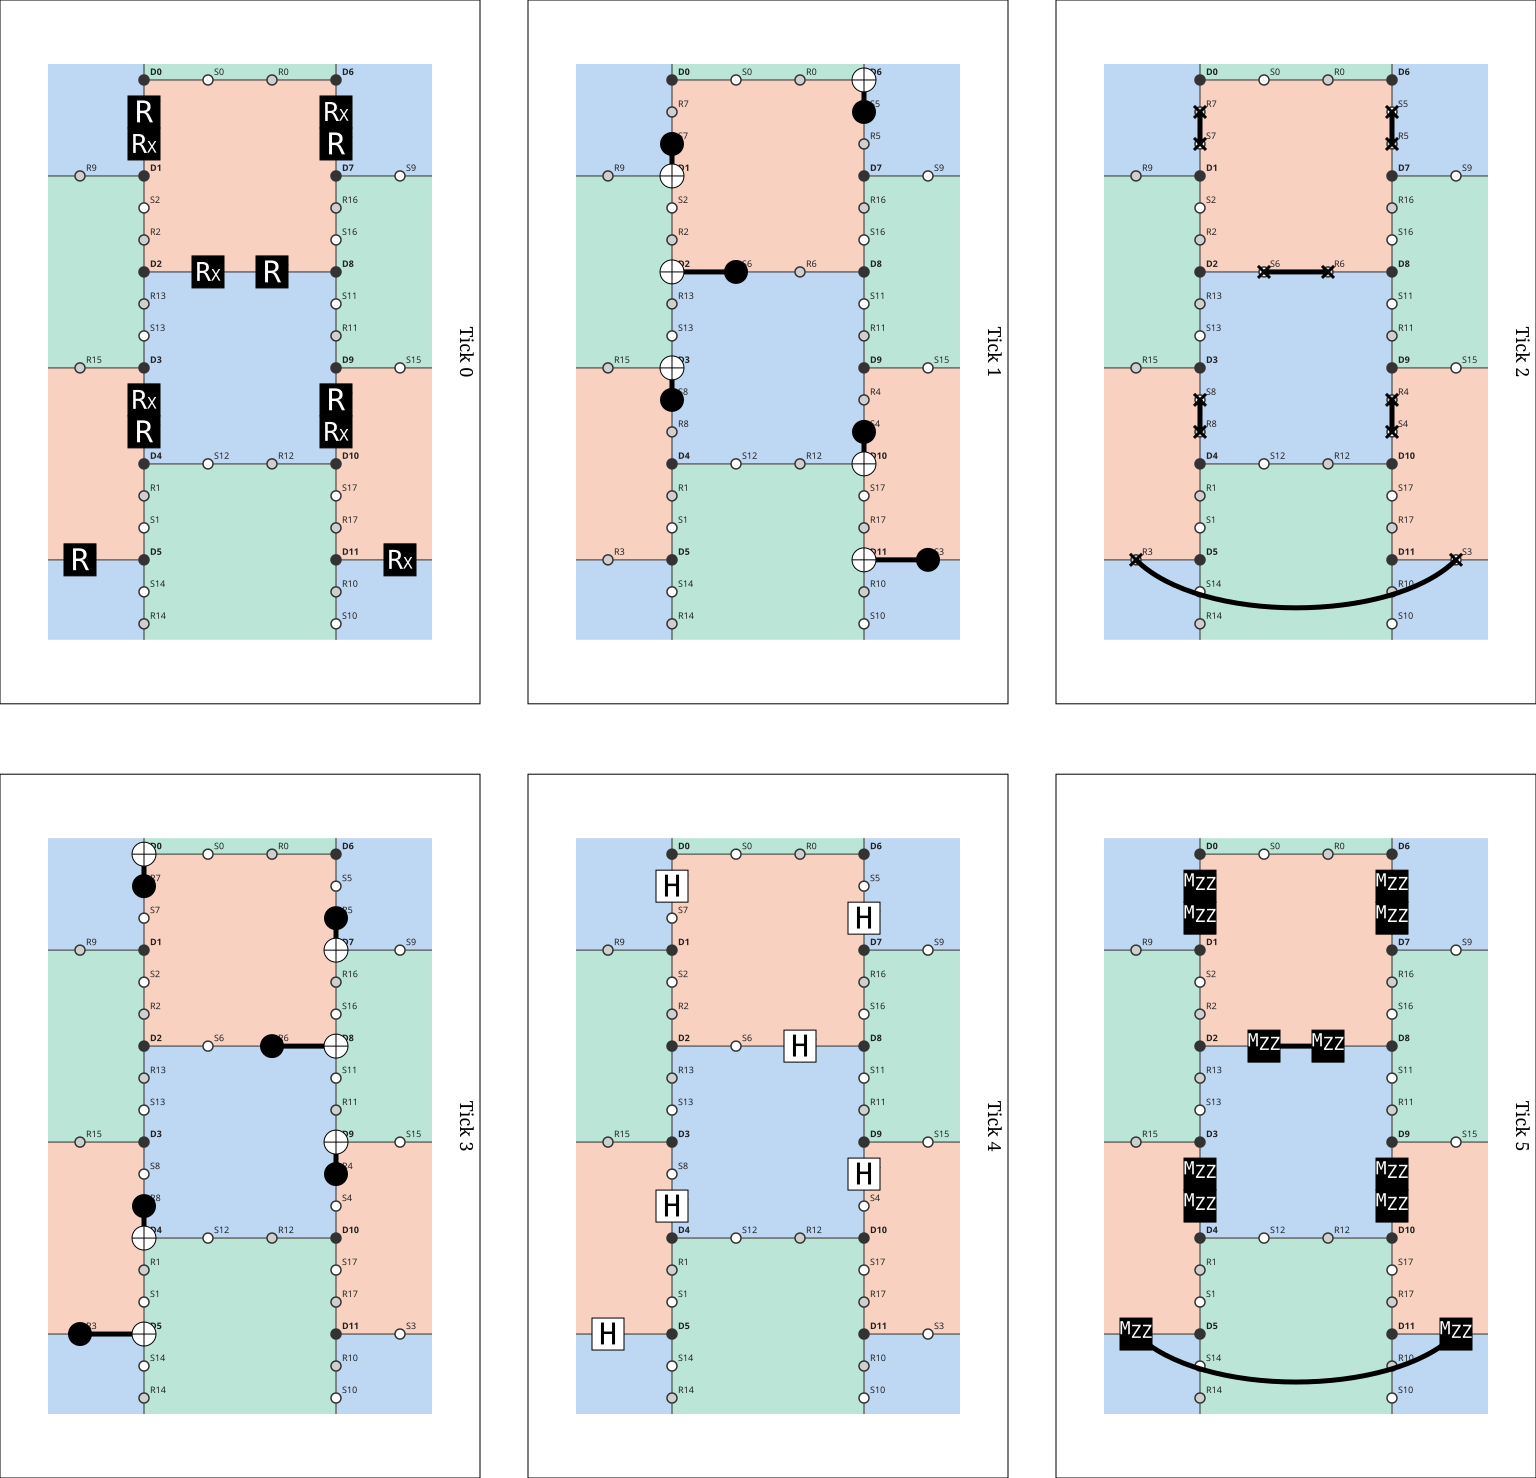

In [32]:
for r in range(3):
    print(f"sub-round {r}")
    display(SVG(round_svg(DRAW_DISTANCE, r, hex_view=False, numbers=NUMBERS)))

The same sub-rounds with the plaquettes drawn as regular hexagons. Only where each qubit is drawn
changes; the circuit is the same.

sub-round 0


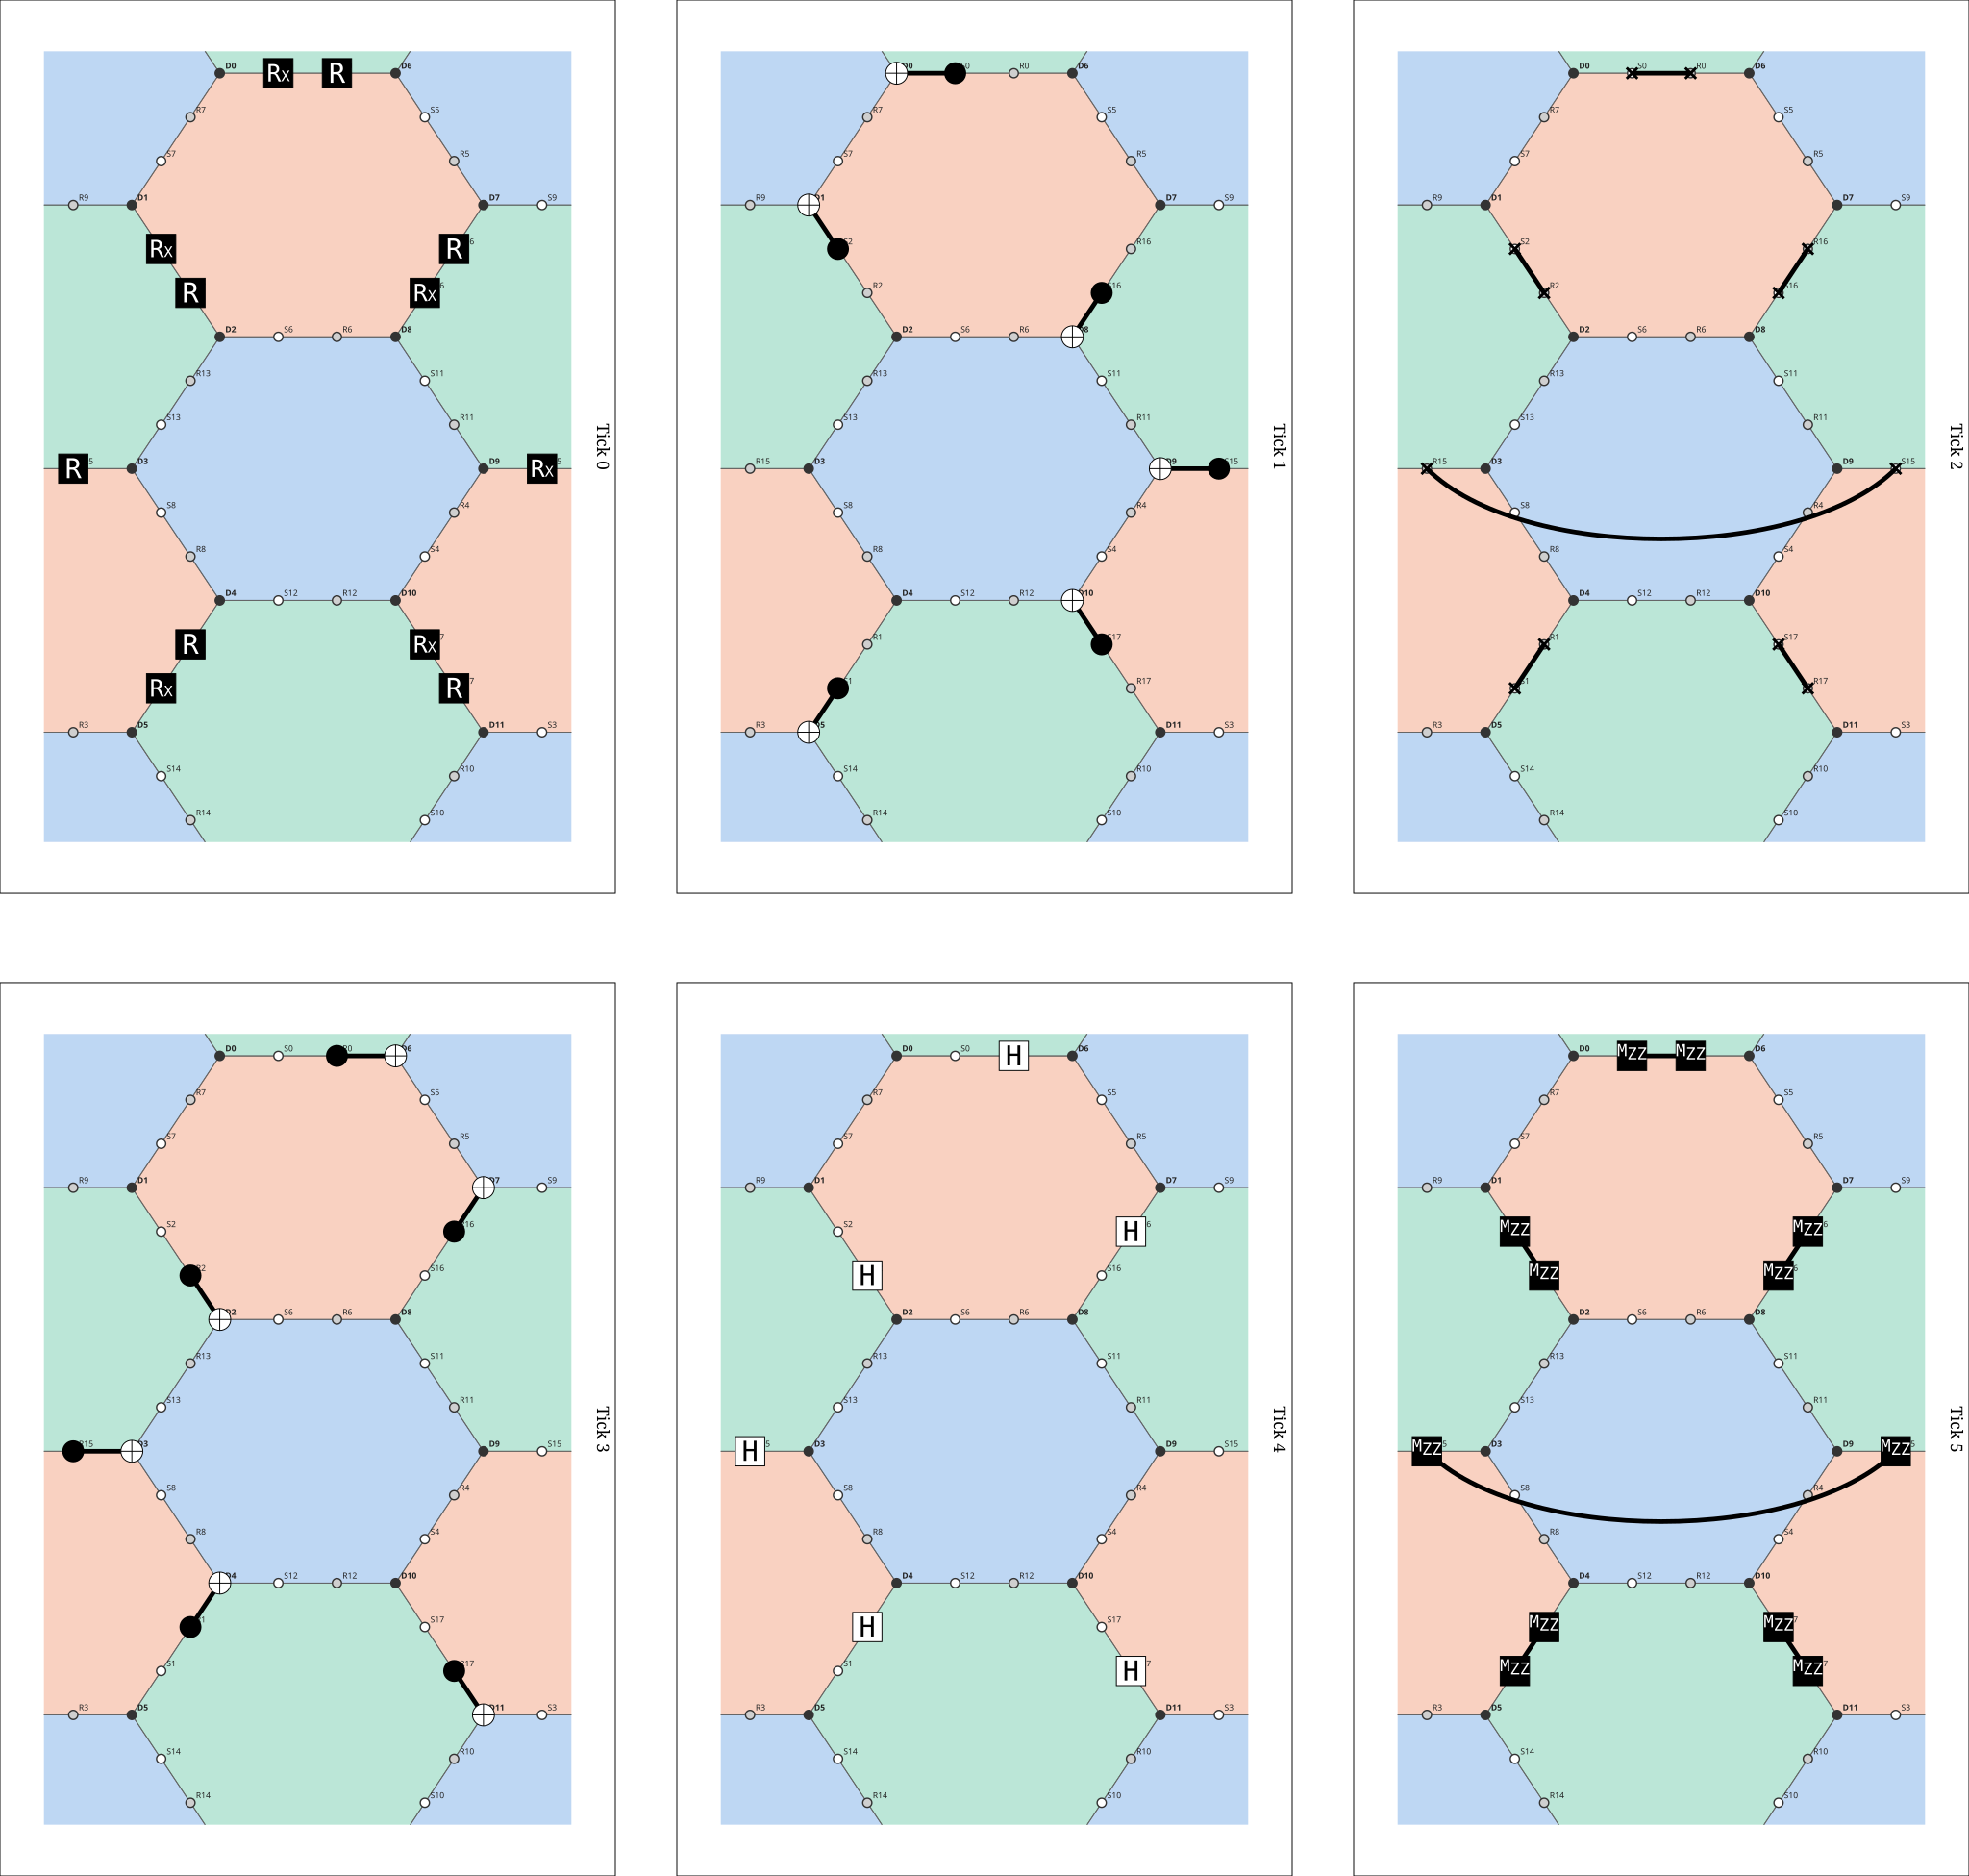

sub-round 1


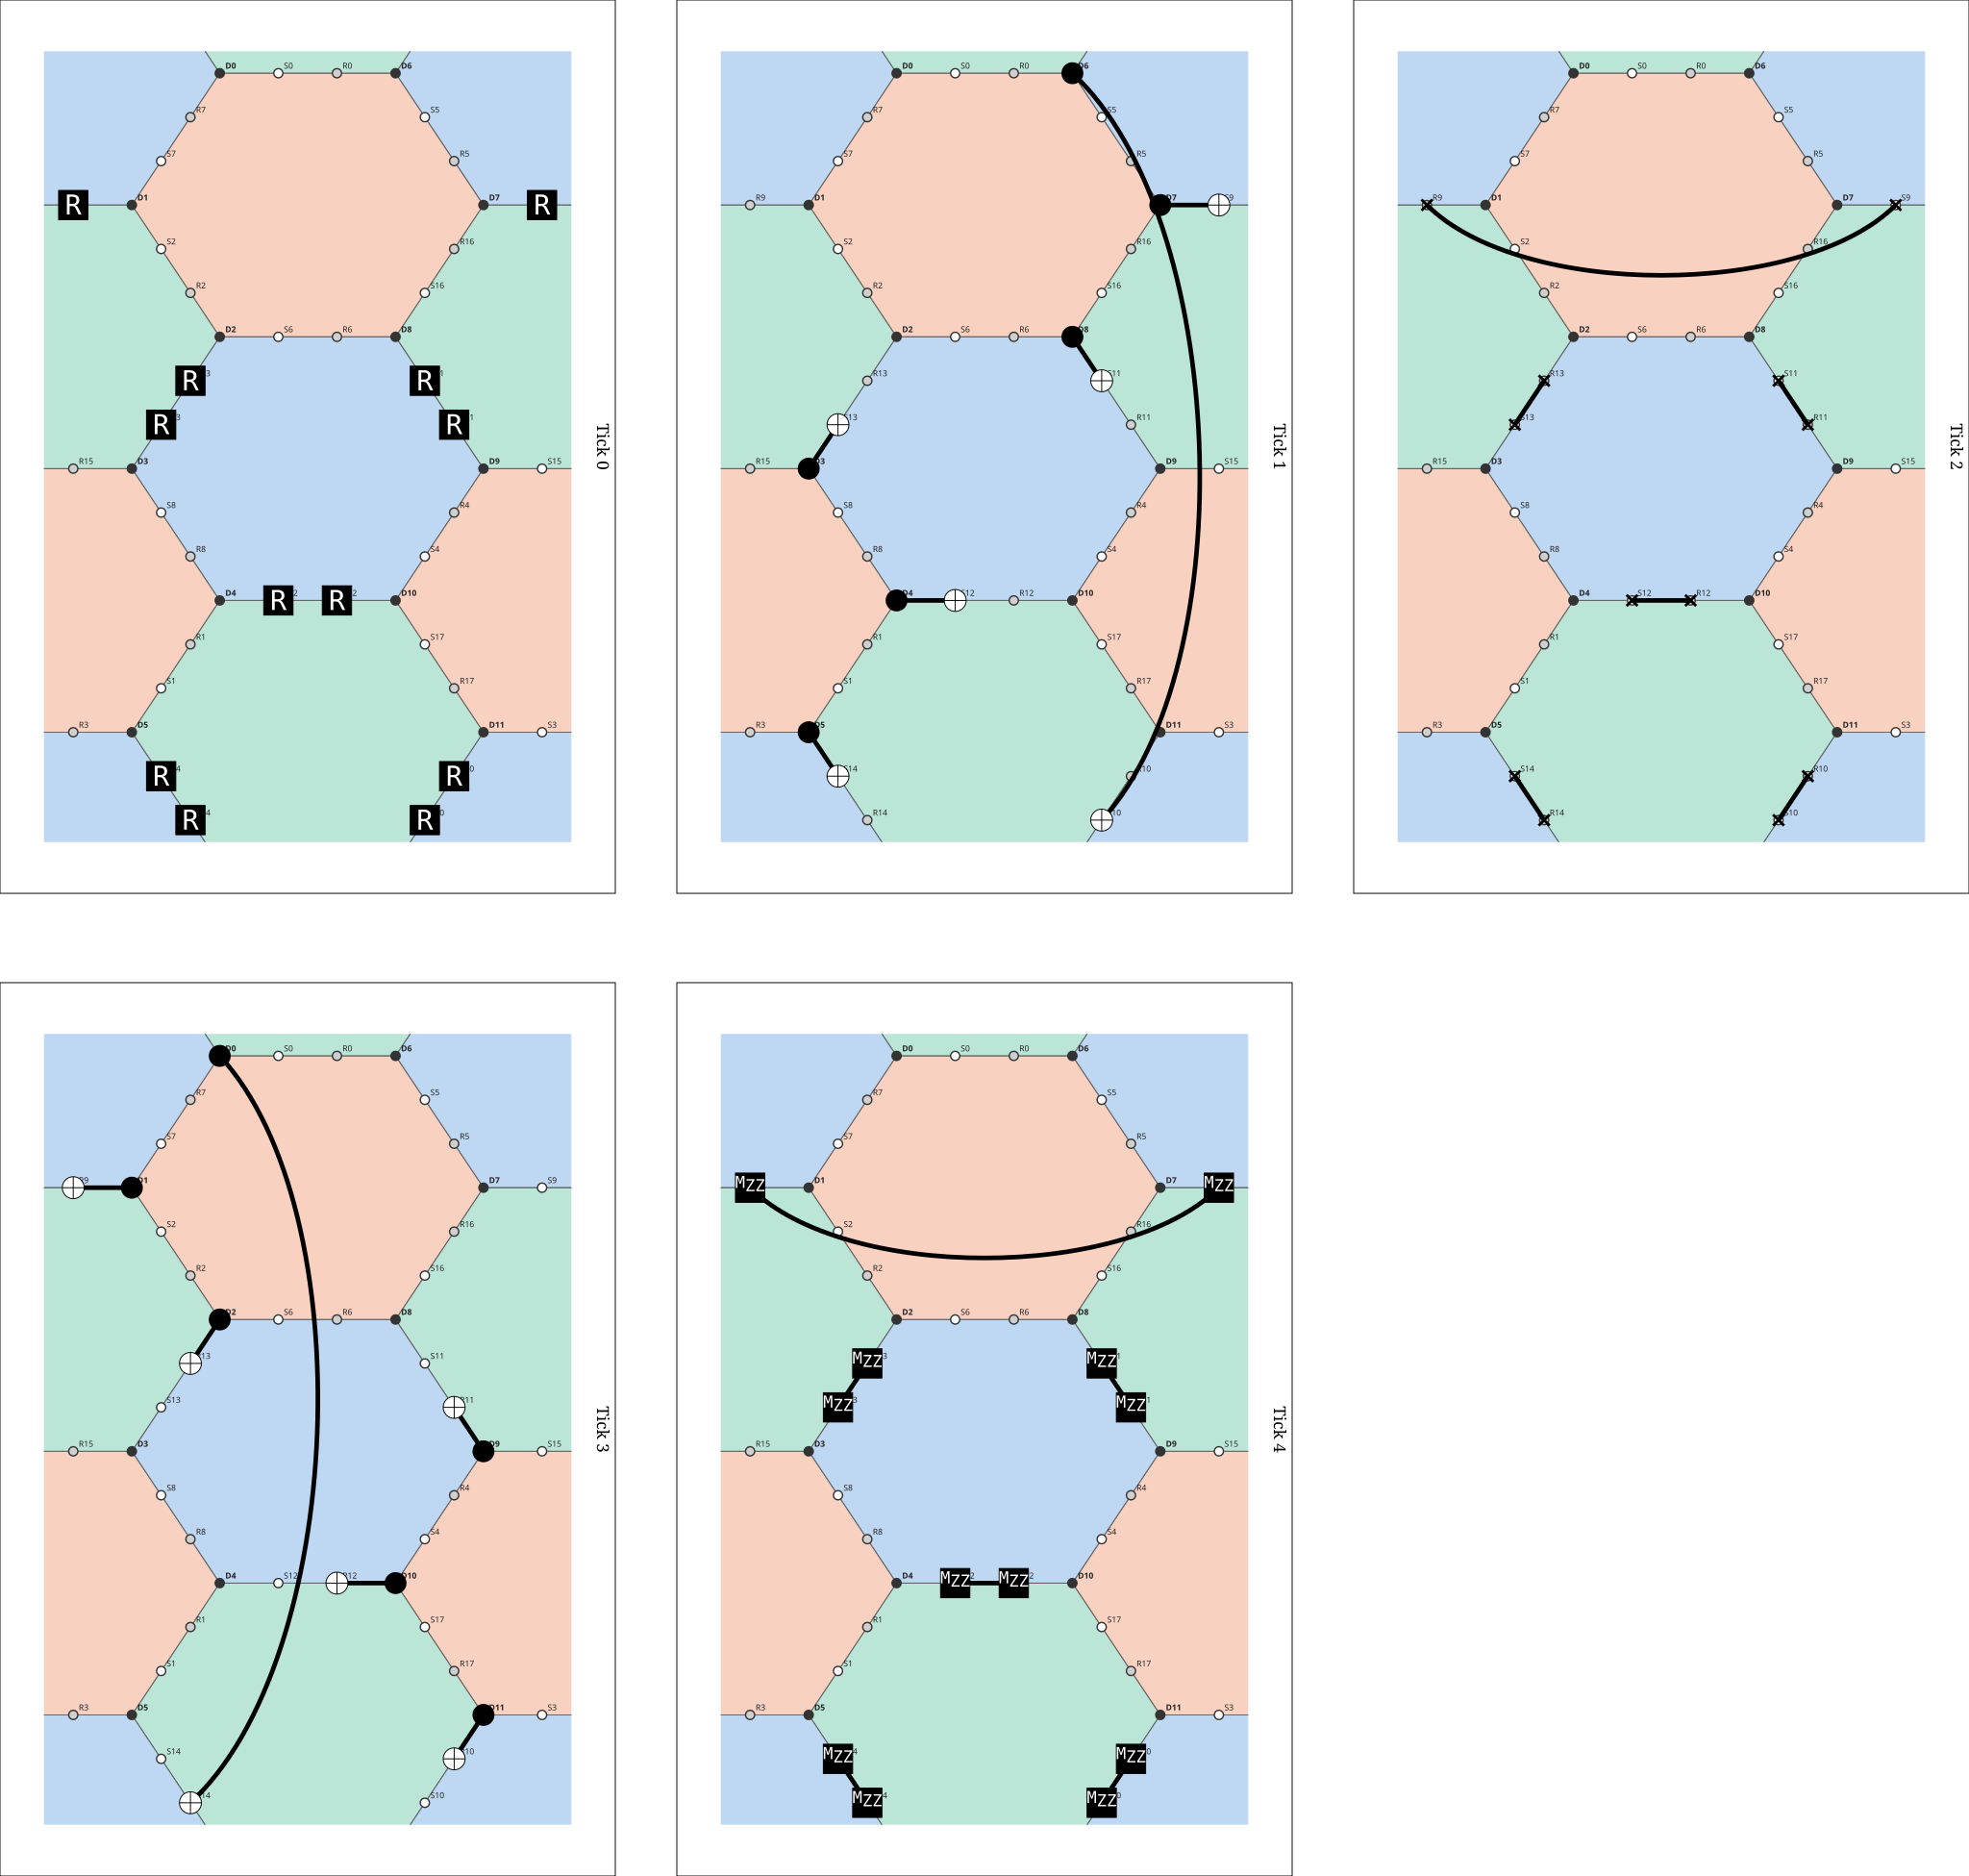

sub-round 2


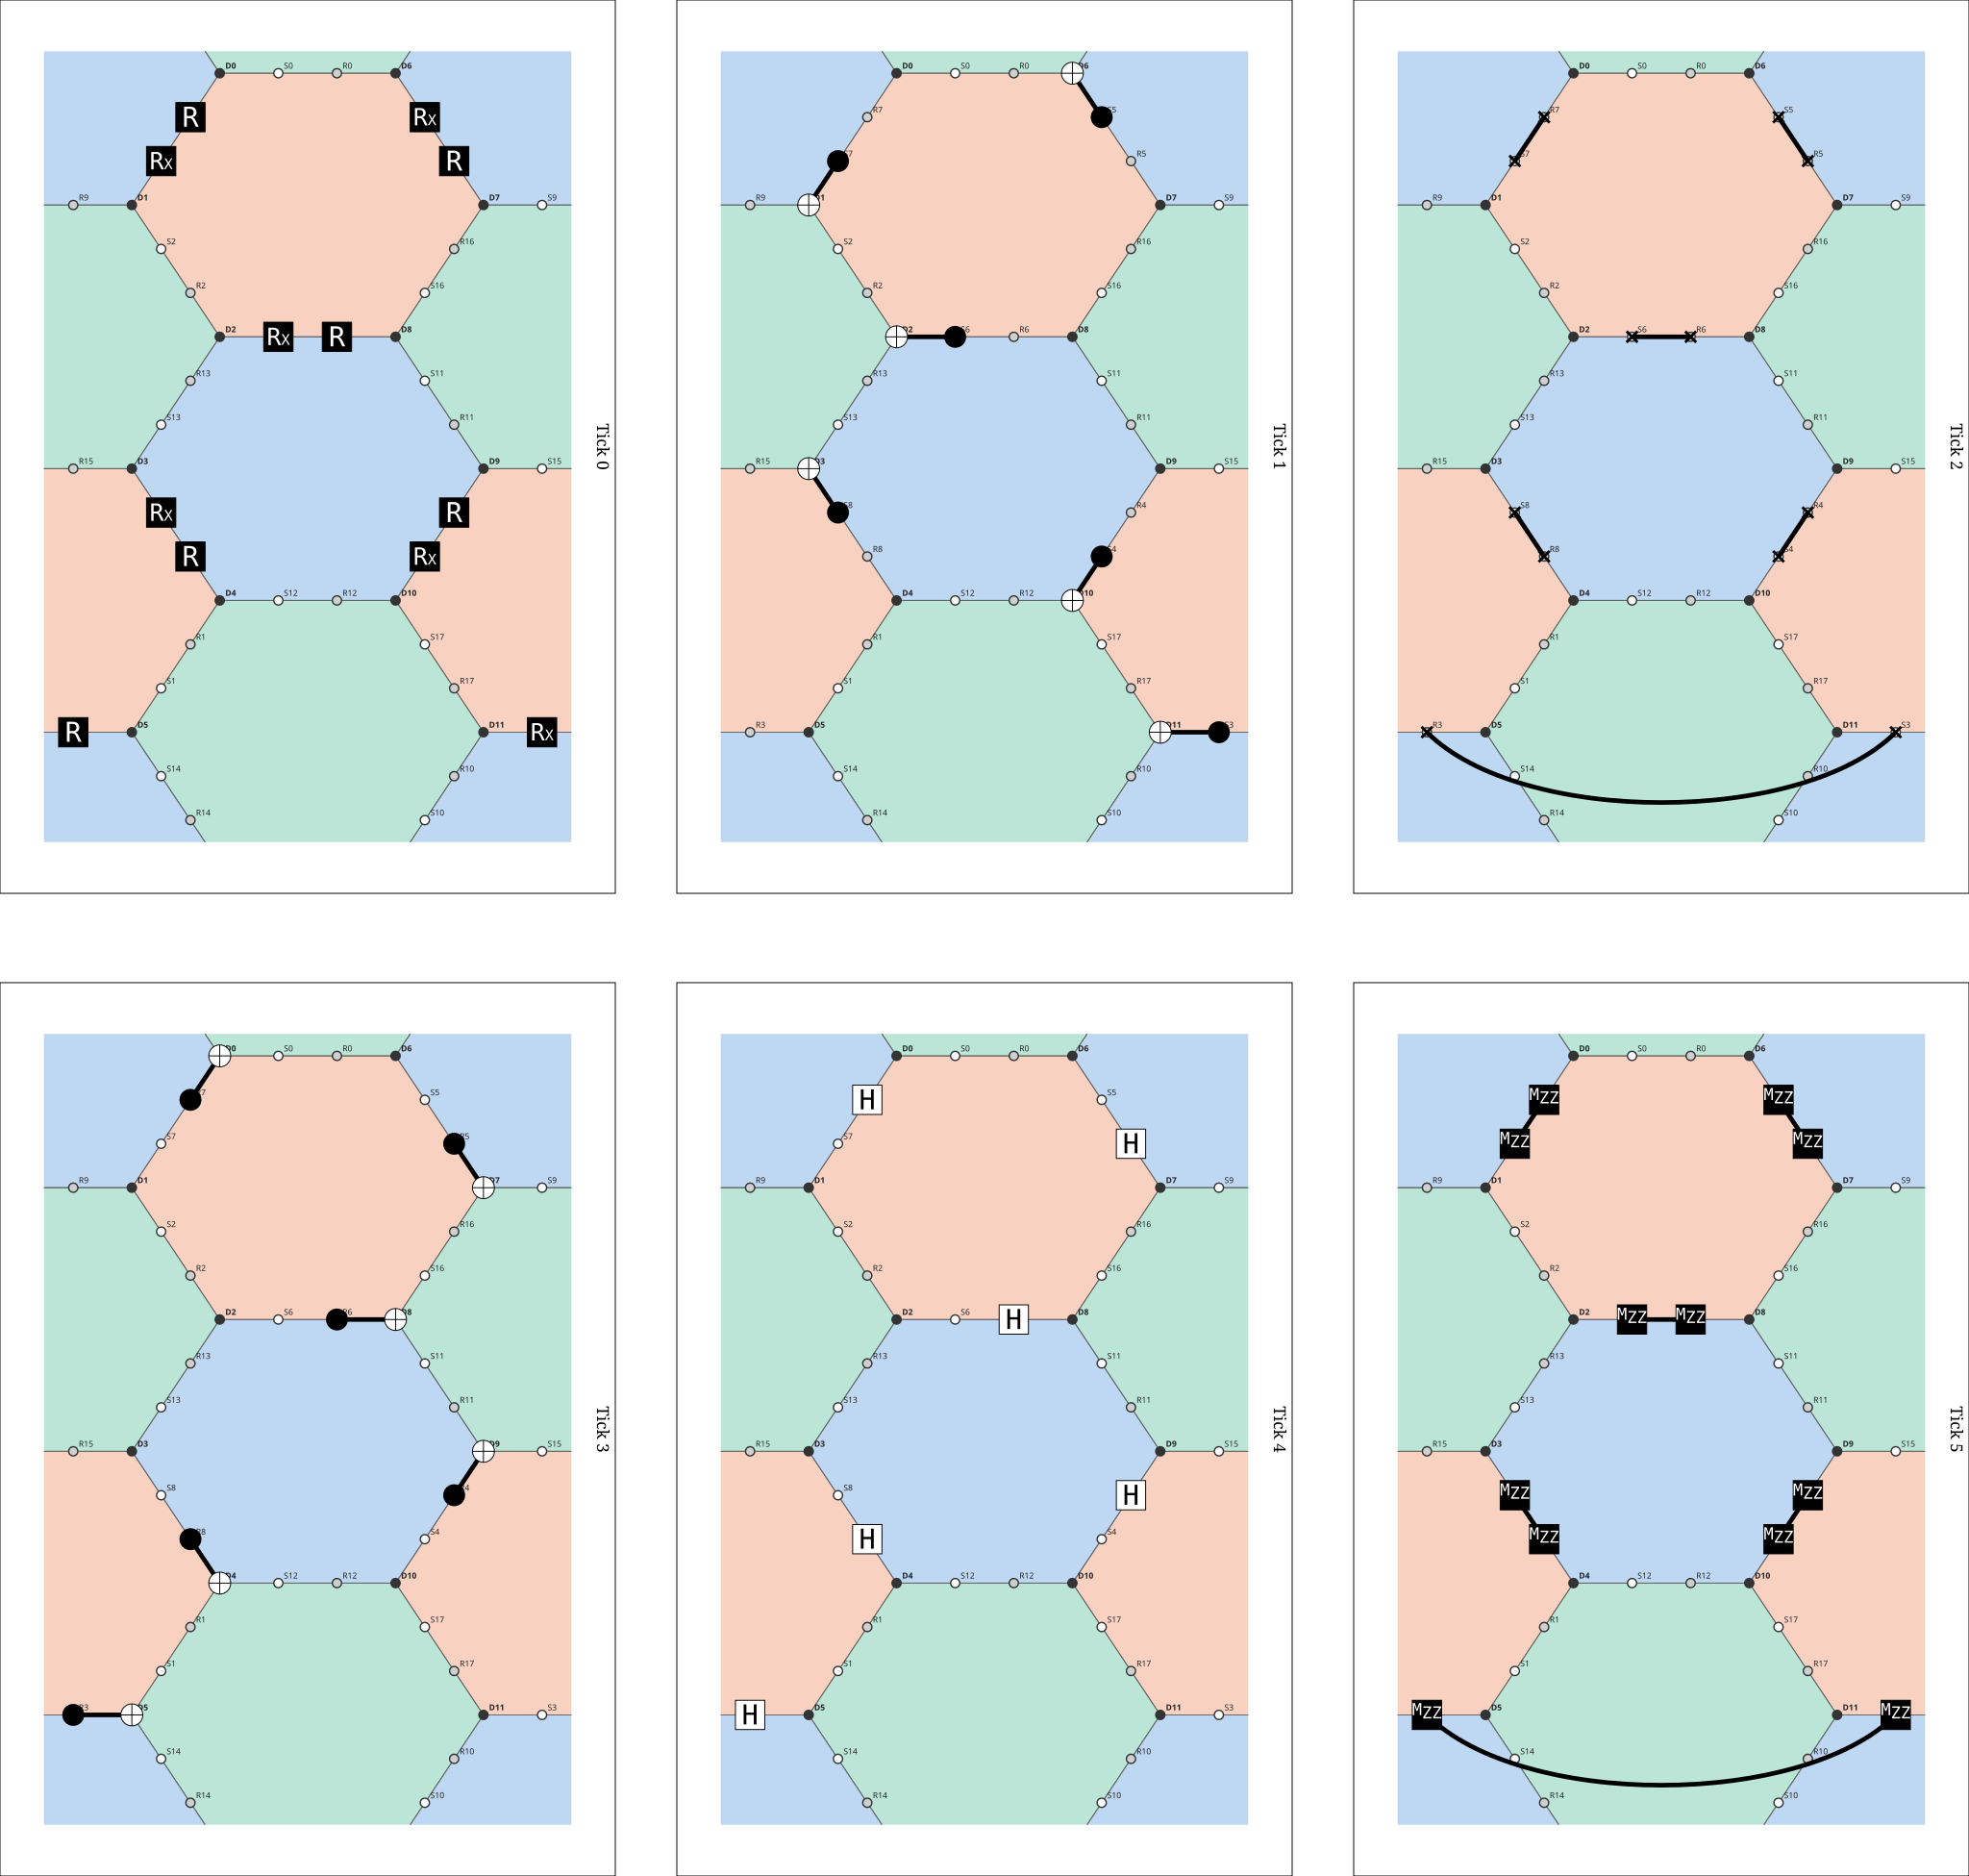

In [33]:
for r in range(3):
    print(f"sub-round {r}")
    display(SVG(round_svg(DRAW_DISTANCE, r, hex_view=True, numbers=NUMBERS)))

## `NOISE` and what p means

p is the two-qubit gate error rate; each model sets every other operation's error as a multiple of it.
The table is total error probability divided by p. A 0 means that channel is off in that model.

In [34]:
p = 1e-3
table = {}
for name, make_model in NOISE_MODELS.items():
    m = make_model(p, ETA)
    table[name] = {
        "reset": m.R_gate.gate_noise_probs,
        "readout": m.M_gate.gate_noise_probs,
        "1-qubit gate": m.H_gate.gate_noise_probs,
        "2-qubit gate": m.CX_gate.gate_noise_probs,
        "SWAP": m.SWAP_gate.gate_noise_probs,
        "idle per layer": m.CX_gate.idle_noise_probs,
        "idle per round": m.round_noise_probs,
    }
print(f"{'error / p':16}" + "".join(f"{name:>8}" for name in table))
for op in table["spin"]:
    print(f"{op:16}" + "".join(f"{sum(t[op] or [0]) / p:>8.3g}" for t in table.values()))

error / p           spin     HBD    MHBD
reset                  2       1       2
readout                5       1       5
1-qubit gate         0.1       1     0.1
2-qubit gate           1       1       1
SWAP                 1.5       1       1
idle per layer       0.1       0       0
idle per round         2       1       2


## `ETA`

How a single-qubit error is split between X, Y and Z (`biased_single_qubit_probabilities`), as fractions of
the total. η = 0.5 is depolarizing; large η is mostly dephasing. Two-qubit channels shift the same way.

In [35]:
for eta in [0.5, 1, 10, 100]:
    px, py, pz = biased_single_qubit_probabilities(1.0, eta)
    print(f"eta = {eta:>5}:  X {px:.3f}  Y {py:.3f}  Z {pz:.3f}")

eta =   0.5:  X 0.333  Y 0.333  Z 0.333
eta =     1:  X 0.250  Y 0.250  Z 0.500
eta =    10:  X 0.045  Y 0.045  Z 0.909
eta =   100:  X 0.005  Y 0.005  Z 0.990


The same d = 3 point at a few biases. How much bias helps or hurts depends on the code, so expect this to
change a lot when the Floquet circuit replaces the surface-code placeholder.

In [36]:
for eta in [0.5, 10, 1000]:
    noisy = add_noise(memory_circuit(3, 3), NOISE_MODELS[NOISE](3e-3, eta))
    print(f"eta = {eta:>6}:  LER {count_logical_errors(noisy, SHOTS) / SHOTS:.2e}")

eta =    0.5:  LER 2.35e-02
eta =     10:  LER 6.78e-03
eta =   1000:  LER 4.83e-03


## `P_MIN`, `P_MAX`, `NUM`

The p values every distance is run at: `NUM` points, log-spaced, both ends included.

In [37]:
ps = list(np.geomspace(P_MIN, P_MAX, NUM))
print(", ".join(f"{p:.2g}" for p in ps))
print(f"{(NUM - 1) / np.log10(P_MAX / P_MIN):g} steps per decade")

0.0001, 0.00018, 0.00032, 0.00056, 0.001, 0.0018, 0.0032, 0.0056, 0.01
4 steps per decade


## `SHOTS`

A point's LER is logical errors / `SHOTS`, so its relative error is about 1/√errors and the smallest LER it
can show is 1/`SHOTS`. Here one point is sampled five times at three shot counts: the spread is the noise
in a single point of the plot below.

In [38]:
noisy = add_noise(memory_circuit(3, 3), NOISE_MODELS[NOISE](2e-3, ETA))
for shots in [1_000, 10_000, 100_000]:
    lers = [count_logical_errors(noisy, shots) / shots for _ in range(5)]
    print(f"SHOTS = {shots:>7}:  " + "  ".join(f"{x:.1e}" for x in lers))

SHOTS =    1000:  1.0e-03  1.0e-03  1.0e-03  3.0e-03  4.0e-03
SHOTS =   10000:  3.5e-03  3.0e-03  2.6e-03  4.1e-03  2.2e-03
SHOTS =  100000:  2.9e-03  3.1e-03  2.9e-03  2.4e-03  3.0e-03


## All together

What `make plots` computes, without writing files. Where the lines cross is the threshold. The placeholder
crosses near p ≈ 1.5%, so set `P_MAX = 3e-2` above to see it. Points with zero logical errors are left out,
because a log axis can't show 0.

d=3:   0%|          | 0/9 [00:00<?, ?it/s]

d=7: 100%|██████████| 9/9 [00:11<00:00,  1.25s/it]


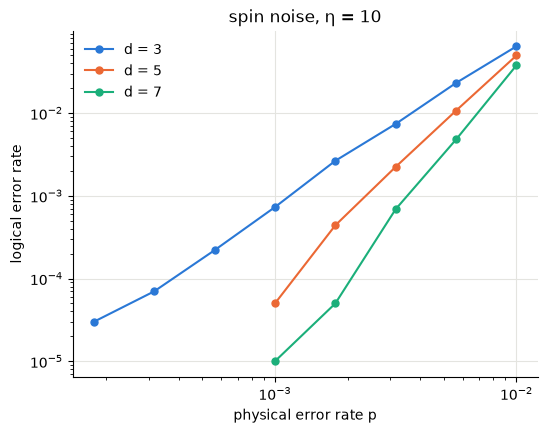

In [39]:
runs = [sweep(d, d, NOISE, ETA, ps, SHOTS) for d in DISTANCES]
fig, ax = plt.subplots(figsize=(6, 4.5))
draw_ler(ax, runs)